# Wavelet MPS worksheet

This worksheet accompanies [*Wavelet Matrix Product States for Quantum Fields*](https://arxiv.org/abs/2606.23823), M. Kaplan and A. Tilloy (2026).

### Setup

This notebook lives in `examples/` and runs in that folder's environment, which contains the wMPS package, its dependencies (MPSKit, TensorKit, OptimKit), and the Plots, LaTeXStrings and Revise packages used below, so nothing needs to be installed separately. The first run instantiates the environment and precompiles, which can take a few minutes.

In [13]:
using Pkg
Pkg.activate(@__DIR__) # the examples environment, which includes wMPS, Plots and Revise
Pkg.instantiate()

using Revise # picks up edits to src/ without restarting Julia; must load before wMPS
using wMPS, MPSKit, TensorKit, OptimKit

  Activating project at `~/Documents/Code/wMPS/wMPS`


## I. Fixed-resolution Lieb-Liniger groundstate optimization

The Lieb-Liniger MPO Hamiltonian is created by calling `LL_D6()`/`LL_D6_minimal()` or `LL_D8()`/`LL_D8_minimal()`, for Daubechies $D6$ and $D8$ wavelets respectively, in `models.jl`. The original code for the paper used `LL_D6()` and `LL_D8()`, which are exact MPO's created by explicit enumeration of all terms. `LL_D6_minimal()` and `LL_D8_minimal()` (or `LL_wavelet_minimal()` for any wavelet order) are exact to machine precision, and much smaller than the original MPO's. We thus use them everywhere below. All MPO's are constructed in the thermodynamic limit, and so they are infinite. MPO's can be constructed for any similar models written in the wavelet basis (see, e.g., `quad_model_D6()`, a simple Gaussian model). To start, we generate the MPO for some choice of the parameters:

* $\mu$: the repulsion coefficient
* $c$: the interaction coefficient
* $r$: the resolution of the MPO, and thus the groundstate we find from optimization
* $d_{max}$: the maximum number of bosons allowed at each site

### Using $D6$ Daubechies wavelets

Let's create the Lieb-Liniger MPO in the basis of $D6$ wavelets, with $\mu=1,c=8,r=2,$ and $d_{max}=2$.

In [14]:
#setting the parameters
μ0=1.0
c0=8.0
r0=2.0
dmax=2

#creating the MPO
H = LL_D6_minimal(; μ=μ0, c=c0, r=r0, cutoff=dmax)

1-site InfiniteMPOHamiltonian(ComplexF64, ComplexSpace) with maximal dimension 45:
| ⋮
| (ℂ^1 ⊞ ℂ^1 ⊞ ℂ^1 ⊞ ⋯ ⊞ ℂ^1 ⊞ ℂ^1 ⊞ ℂ^1)
┼─[1]─ ℂ^3
│ (ℂ^1 ⊞ ℂ^1 ⊞ ℂ^1 ⊞ ⋯ ⊞ ℂ^1 ⊞ ℂ^1 ⊞ ℂ^1)
| ⋮


$H$ is an InfiniteMPOHamiltonian object. We can now use built-in optimization algorithms from MPSKit.jl, like VUMPS or Grassmann gradient descent, to perform the groundstate optimization. We just need to choose the bond dimension $D$ of the states we optimize over; here we take $D=12$. We also have the freedom to choose the optimization parameters, like the number of iterations or the tolerance for convergence. For illustration purposes, below we run VUMPS with a tolerance of $10^{-3}$. We then run LBFGS with a memory of 100 and a tolerance of $10^{-5}$. After each of these routines we save the energy of the state.

When using `GradientGrassmann()` from `MPSKit`, we found that setting a smaller `metric_regulator` led to performance improvements. We implement this smaller regulator (with value 1e-8) as the default for find_groundstate_t(). This is a function parameter that can be toggled.

In [15]:
D=12 #MPS bond dimension
state = InfiniteMPS(dmax+1, D) #random initial state

#VUMPS routine
tol=1e-3
println("Running VUMPS with: maximum $dmax boson(s) per site, resolution $r0, bond dimension $D, and tolerance $tol")
groundstate, cache, delta = find_groundstate(state, H, VUMPS(; tol=tol)) #running VUMPS
E = real(expectation_value(groundstate, H)) #groundstate energy after VUMPS
println("Groundstate energy after VUMPS: $E")

#Gradient descent routine
memory=100
tol_gg=1e-5
alg_gg = OptimKit.LBFGS(memory; gradtol=tol_gg, verbosity=3) #algorithm for gradient descent
println("Running Grassmann Gradient descent with: maximum $dmax boson(s) per site, resolution $r0, bond dimension $D, and tolerance $tol_gg")
groundstate_gg, cache, delta = find_groundstate_t(groundstate, H, GradientGrassmann(; method=alg_gg));
E_gg = real(expectation_value(groundstate_gg, H)) #groundstate energy
println("Groundstate energy after gradient descent: $E_gg")

Running VUMPS with: maximum 2 boson(s) per site, resolution 2.0, bond dimension 12, and tolerance 0.001


┌ Info: VUMPS init:	obj = +2.575869489280e+02	err = 4.2967e-01
└ @ MPSKit /Users/mollykaplan/.julia/packages/MPSKit/7FTCR/src/algorithms/groundstate/vumps.jl:69
┌ Info: VUMPS   1:	obj = +2.386213953430e+00	err = 4.3986780783e-01	time = 0.09 sec
└ @ MPSKit /Users/mollykaplan/.julia/packages/MPSKit/7FTCR/src/algorithms/groundstate/vumps.jl:80
┌ Info: VUMPS   2:	obj = -5.790205989304e-02	err = 3.2299752966e-01	time = 0.09 sec
└ @ MPSKit /Users/mollykaplan/.julia/packages/MPSKit/7FTCR/src/algorithms/groundstate/vumps.jl:80
┌ Info: VUMPS   3:	obj = -1.517641923650e-01	err = 1.8886249588e-01	time = 0.09 sec
└ @ MPSKit /Users/mollykaplan/.julia/packages/MPSKit/7FTCR/src/algorithms/groundstate/vumps.jl:80
┌ Info: VUMPS   4:	obj = -1.908220986073e-01	err = 1.2953239859e-01	time = 0.10 sec
└ @ MPSKit /Users/mollykaplan/.julia/packages/MPSKit/7FTCR/src/algorithms/groundstate/vumps.jl:80
┌ Info: VUMPS   5:	obj = -2.110060200609e-01	err = 3.5713211279e-02	time = 0.10 sec
└ @ MPSKit /Users/mollykapl

Groundstate energy after VUMPS: -0.22325863140985314
Running Grassmann Gradient descent with: maximum 2 boson(s) per site, resolution 2.0, bond dimension 12, and tolerance 1.0e-5


┌ Info: LBFGS: initializing with f = -2.232586314099e-01, ‖∇f‖ = 1.7480e-02
└ @ wMPS /Users/mollykaplan/Documents/Code/wMPS/wMPS/src/timing.jl:100
┌ Info: LBFGS: iter    1, Δt  84.0 ms: f = -2.232590009175e-01, ‖∇f‖ = 9.1872e-03, α = 1.00e+00, m = 0, nfg = 1
└ @ wMPS /Users/mollykaplan/Documents/Code/wMPS/wMPS/src/timing.jl:159
┌ Info: LBFGS: iter    2, Δt  83.1 ms: f = -2.232591713271e-01, ‖∇f‖ = 5.4476e-03, α = 1.00e+00, m = 1, nfg = 1
└ @ wMPS /Users/mollykaplan/Documents/Code/wMPS/wMPS/src/timing.jl:159
┌ Info: LBFGS: iter    3, Δt  83.5 ms: f = -2.232595917390e-01, ‖∇f‖ = 5.1288e-03, α = 1.00e+00, m = 2, nfg = 1
└ @ wMPS /Users/mollykaplan/Documents/Code/wMPS/wMPS/src/timing.jl:159
┌ Info: LBFGS: iter    4, Δt  85.1 ms: f = -2.232598727554e-01, ‖∇f‖ = 5.9778e-03, α = 1.00e+00, m = 3, nfg = 1
└ @ wMPS /Users/mollykaplan/Documents/Code/wMPS/wMPS/src/timing.jl:159
┌ Info: LBFGS: iter    5, Δt 160.8 ms: f = -2.232600253010e-01, ‖∇f‖ = 6.9607e-03, α = 5.04e-01, m = 4, nfg = 2
└ @ wMPS 

Groundstate energy after gradient descent: -0.22326098639316372


### Using $D8$ Daubechies wavelets

To work with $D8$ wavelets, we can follow the same procedure as above, except now using `LL_D8_minimal()` to create the infinite MPO. Note that the number of terms in the MPO must increase signficantly if we use $D8$ wavelets, because wavelets have larger support at higher order, and so there will be new terms connecting lattice sites farther apart. Thus, optimization algorithms like VUMPS and gradient descent will run slower than for the $D6$ wavelets.

In [16]:
#creating the MPO
H8 = LL_D8_minimal(; μ=μ0, c=c0, r=r0, cutoff=dmax)

D=12 #MPS bond dimension
state8 = InfiniteMPS(dmax+1, D) #random initial state

#VUMPS routine
tol=1e-3
println("Running VUMPS with: maximum $dmax boson(s) per site, resolution $r0, bond dimension $D, and tolerance $tol")
groundstate8, cache, delta = find_groundstate(state8, H8, VUMPS(; tol=tol)) #running VUMPS
E8 = real(expectation_value(groundstate8, H8)) #groundstate energy after VUMPS
println("Groundstate energy after VUMPS: $E8")

#Gradient descent routine
memory=100
tol_gg=1e-5
alg_gg = OptimKit.LBFGS(memory; gradtol=tol_gg, verbosity=3) #algorithm for gradient descent
println("Running Grassmann Gradient descent with: maximum $dmax boson(s) per site, resolution $r0, bond dimension $D, and tolerance $tol_gg")
groundstate8_gg, cache, delta = find_groundstate_t(groundstate8, H8, GradientGrassmann(; method=alg_gg));
E8_gg = real(expectation_value(groundstate8_gg, H8)) #groundstate energy
println("Groundstate energy after gradient descent: $E8_gg")

Running VUMPS with: maximum 2 boson(s) per site, resolution 2.0, bond dimension 12, and tolerance 0.001


┌ Info: VUMPS init:	obj = +1.934345896205e+02	err = 4.4847e-01
└ @ MPSKit /Users/mollykaplan/.julia/packages/MPSKit/7FTCR/src/algorithms/groundstate/vumps.jl:69
┌ Info: VUMPS   1:	obj = -7.178154971631e-02	err = 3.3669835816e-01	time = 0.64 sec
└ @ MPSKit /Users/mollykaplan/.julia/packages/MPSKit/7FTCR/src/algorithms/groundstate/vumps.jl:80
┌ Info: VUMPS   2:	obj = -1.445701180921e-01	err = 2.2085045078e-01	time = 0.65 sec
└ @ MPSKit /Users/mollykaplan/.julia/packages/MPSKit/7FTCR/src/algorithms/groundstate/vumps.jl:80
┌ Info: VUMPS   3:	obj = -1.882982390307e-01	err = 1.4659365172e-01	time = 0.65 sec
└ @ MPSKit /Users/mollykaplan/.julia/packages/MPSKit/7FTCR/src/algorithms/groundstate/vumps.jl:80
┌ Info: VUMPS   4:	obj = -2.102330322002e-01	err = 5.6909583122e-02	time = 0.66 sec
└ @ MPSKit /Users/mollykaplan/.julia/packages/MPSKit/7FTCR/src/algorithms/groundstate/vumps.jl:80
┌ Info: VUMPS   5:	obj = -2.174004392060e-01	err = 5.5103034875e-02	time = 0.67 sec
└ @ MPSKit /Users/mollykapl

Groundstate energy after VUMPS: -0.22532287180771637
Running Grassmann Gradient descent with: maximum 2 boson(s) per site, resolution 2.0, bond dimension 12, and tolerance 1.0e-5


┌ Info: LBFGS: initializing with f = -2.253228718077e-01, ‖∇f‖ = 9.7319e-03
└ @ wMPS /Users/mollykaplan/Documents/Code/wMPS/wMPS/src/timing.jl:100
┌ Info: LBFGS: iter    1, Δt  1.26 s: f = -2.253232656014e-01, ‖∇f‖ = 3.9712e-03, α = 4.61e-01, m = 0, nfg = 2
└ @ wMPS /Users/mollykaplan/Documents/Code/wMPS/wMPS/src/timing.jl:159
┌ Info: LBFGS: iter    2, Δt  2.55 s: f = -2.253240676089e-01, ‖∇f‖ = 6.0534e-03, α = 9.95e+00, m = 1, nfg = 4
└ @ wMPS /Users/mollykaplan/Documents/Code/wMPS/wMPS/src/timing.jl:159
┌ Info: LBFGS: iter    3, Δt  1.28 s: f = -2.253242640605e-01, ‖∇f‖ = 4.0973e-03, α = 3.98e-01, m = 2, nfg = 2
└ @ wMPS /Users/mollykaplan/Documents/Code/wMPS/wMPS/src/timing.jl:159
┌ Info: LBFGS: iter    4, Δt 636.3 ms: f = -2.253243633130e-01, ‖∇f‖ = 3.0549e-03, α = 1.00e+00, m = 3, nfg = 1
└ @ wMPS /Users/mollykaplan/Documents/Code/wMPS/wMPS/src/timing.jl:159
┌ Info: LBFGS: iter    5, Δt 641.1 ms: f = -2.253246575627e-01, ‖∇f‖ = 6.7094e-03, α = 1.00e+00, m = 4, nfg = 1
└ @ wMPS /Us

Groundstate energy after gradient descent: -0.22532604097948575


## II. Calculating correlators

Now that we have an approximation for the groundstate, we can calculate expectation values of observables. Implemented in `correlators.jl` are the two-point and density-density correlation functions. These give the correlators at any $x$; below we show how to plot these for a range of $x$ values. Below we show examples for the state with $D6$ wavelets at resolution $2$, which could then be compared to correlators at different resolutions.

### Two-point correlation function

Calculating and plotting $\langle \psi^\dag(x) \psi(0) \rangle$, using `correlator_x()`.

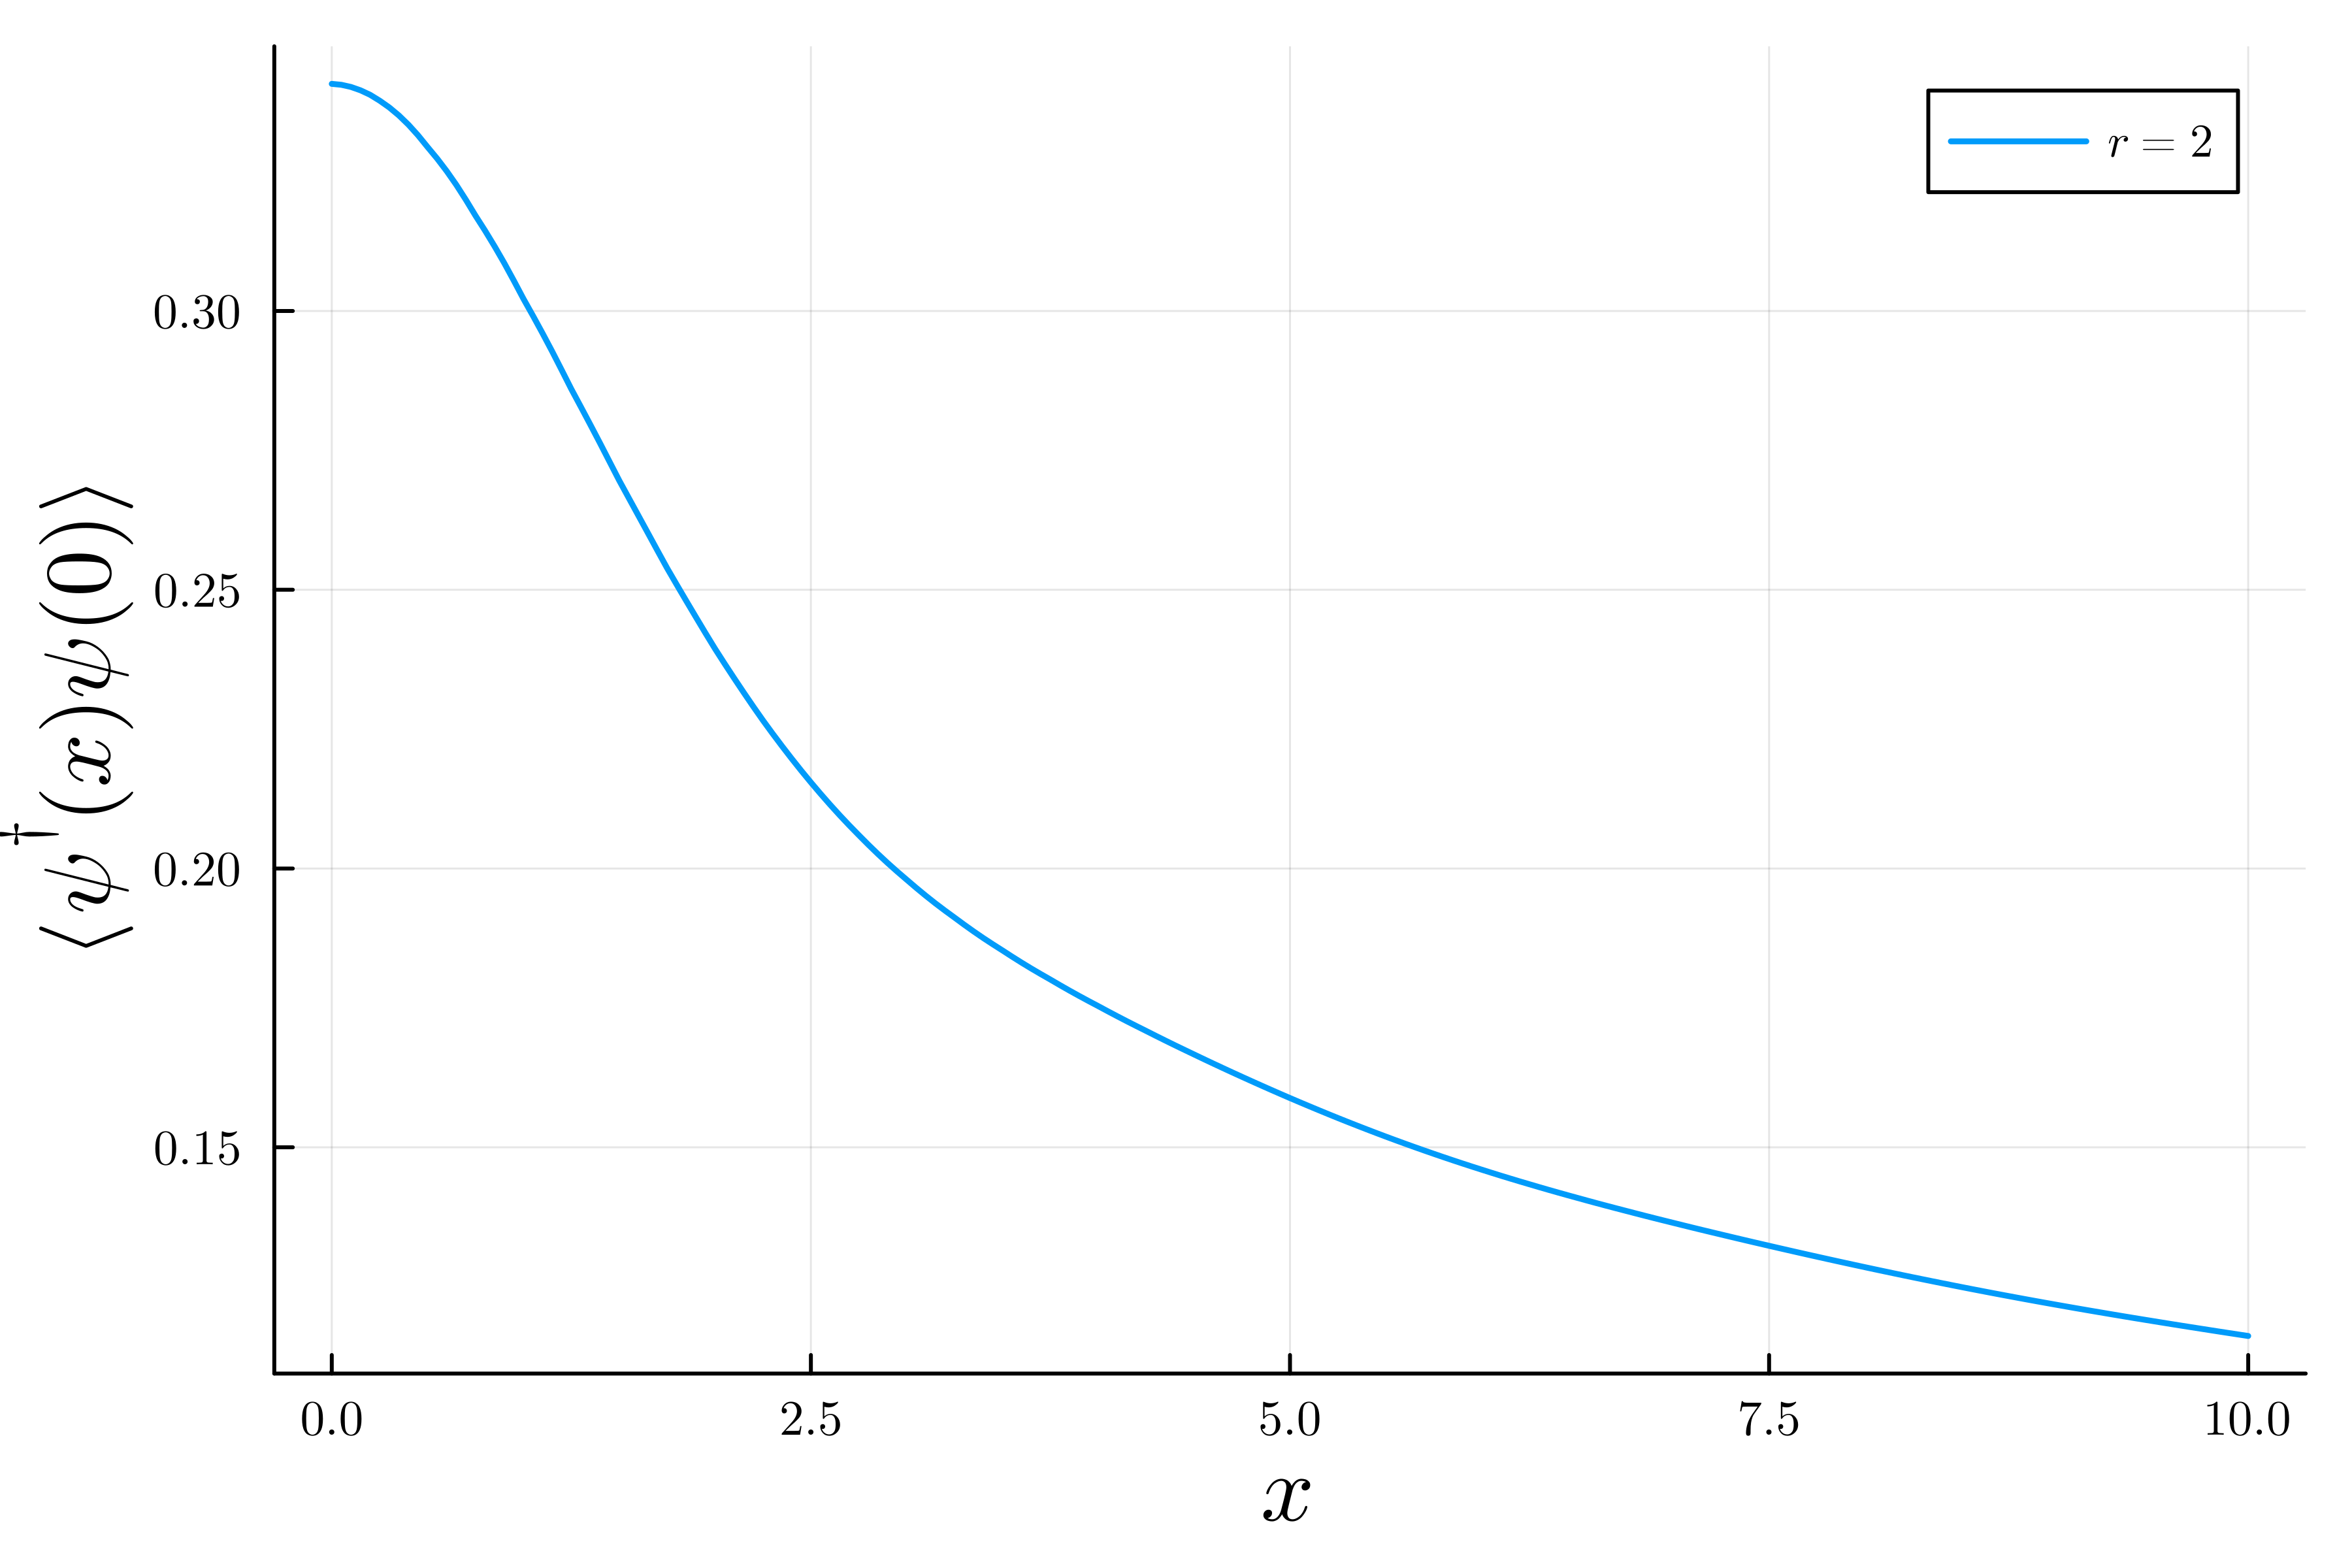

In [17]:
using Plots, LaTeXStrings

#creating arrays of x values
xmax=10
xvals=0:(wMPS.dx):xmax

#the 2-pt correlator for all x in xvals
ψ=groundstate_gg
ψψ=zeros(length(xvals))
for (i,x) in enumerate(xvals)
    ψψ[i] = correlator_x(x, ψ, wMPS.dx, 2)
end

#Plotting
plot(xvals, 
    ψψ,
    linewidth=1.5,
    seriestype=:line,
    label=L"r=2",
    dpi=600,
    xguidefontsize=16, 
    yguidefontsize=16,
    fontfamily = "Computer Modern"
)
Plots.xlabel!(L"x")
Plots.ylabel!(L"⟨ψ^†(x)ψ(0)⟩")


### Density-density correlation function

Calculating and plotting $\langle \psi^\dag(x) \psi^\dag(0) \psi(x) \psi(0) \rangle$, using `density_correlator()`. This one takes a bit more time to evaluate.

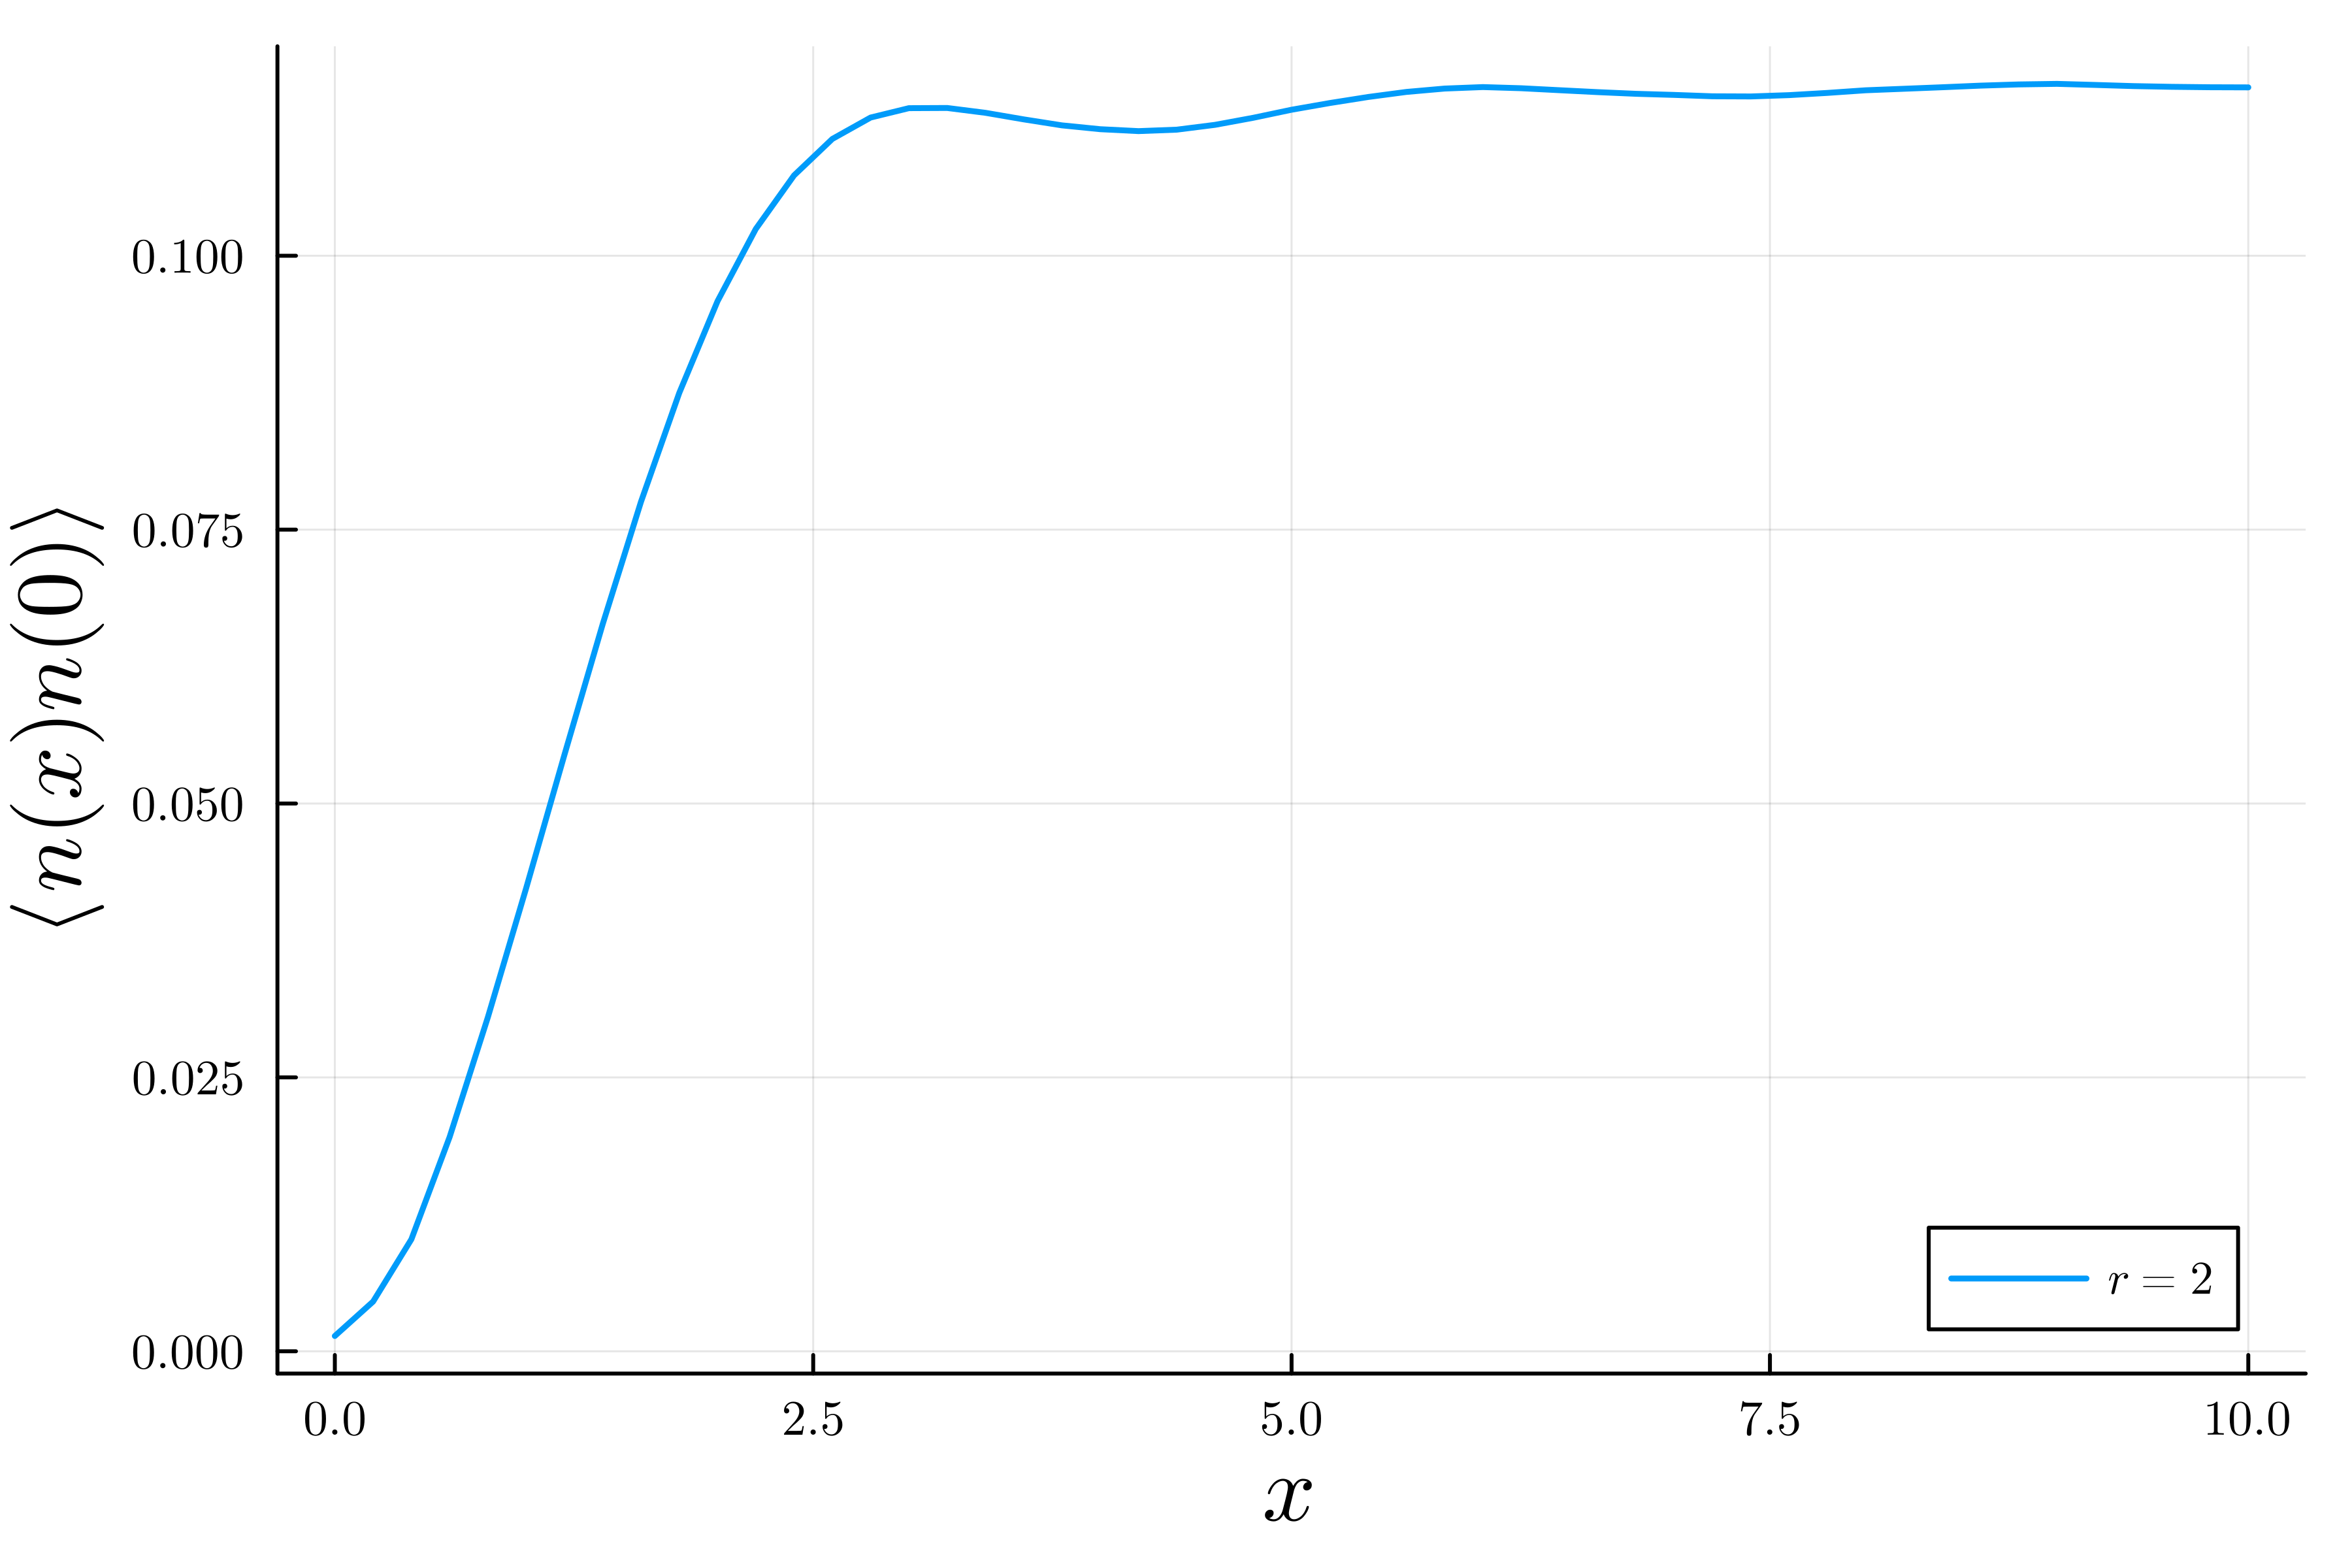

In [18]:
#creating array of x values, fewer points so it runs more quickly
xvals=0:(4*wMPS.dx):xmax

#the density-density correlator for all x in xvals
ψ=groundstate_gg
nn=zeros(length(xvals))
for (i,x) in enumerate(xvals)
    nn[i] = density_correlator(x, ψ, wMPS.dx, 2)
end

#Plotting
plot(xvals, 
    nn,
    linewidth=1.5,
    seriestype=:line,
    label=L"r=2",
    dpi=600,
    xguidefontsize=16, 
    yguidefontsize=16,
    fontfamily = "Computer Modern"
)
Plots.xlabel!(L"x")
Plots.ylabel!(L"⟨n(x)n(0)⟩")

## III. Refining the groundstate

If one wants to go from a state at $r=2$ to one at $r=3$, it is possible to refine the state via the circuit implemented in `MPSrefine()`. This results in a two-site MPS with energy density close the the energy density of the original $r=2$ state. One can then run `single_site()` to approximate this two-site MPS as a single-site one. This is often faster then re-running the code in Section I at higher resolution, especially when the desired $r$ is large.

In [19]:
#one round of refinement
println("Groundstate energy before refinement, resolution $r0: $E_gg")
ψ=groundstate_gg
Hr1 = LL_D6_minimal(; μ=μ0, c=c0, r=r0+1, cutoff=dmax)
Hr1_2 = InfiniteMPOHamiltonian([Hr1[1], Hr1[1]])

#refining to resolution 3, result is a 2-site state
println("Refining in scale, ending with a 2-site state at r=$(r0+1) with bond dimension $D")
state_refined, refine_elapsed, = @timed MPSrefine(ψ, Hr1_2, dmax, dmax+1, D ; )
println("Time to refine, in seconds: $refine_elapsed")
state_2site = state_refined[1]

#writing the two-site MPS as a single-site MPS
state_single, single_elapsed, = @timed single_site(state_2site, Hr1)
println("Time to make a single-site MPS, in seconds: $single_elapsed")

Groundstate energy before refinement, resolution 2.0: -0.22326098639316372
Refining in scale, ending with a 2-site state at r=3.0 with bond dimension 12
Reducing bond dimension to 12
Groundstate energy density after refinement: -0.22329098485893947
Time to refine, in seconds: 0.474892709
Energy density of single-site MPS from tensor A: -0.2230996466627557
Energy density of single-site MPS from tensor B: -0.22607964232333772
Time to make a single-site MPS, in seconds: 0.388502416


Note how much the energy drops just from the approximate projection onto single-site MPS. This energy drop is visualized below, where we run the `refine_optim()` function, from `refinement.jl`. This function performs $n_{scale}$ successive refinements (with single-site projection), with $gg_fg$ iterations of L-BFGS optimization in between each refinement. This scheme quickly reduces the energy of the approximate groundstate. One could then further optimize the final state to reach convergence.

We plot the relative error from the exact Lieb-Liniger energy density, in log-scale, versus the amount of elapsed time. The stair-steps show each jump in resolution.

It is also possible to run successive refinements without optimization, which can be done using `refinement_alg()`.

Starting energy: -0.22326098639316372
Refining in scale, ending with a 2-site state at r=3 with bond dimension 12
Reducing bond dimension to 12
Groundstate energy density after refinement: -0.22329098485893947
Time to refine, in seconds: 0.471262708
Energy density of single-site MPS from tensor A: -0.2230996466627557
Energy density of single-site MPS from tensor B: -0.22607964232333772
Time to make a single-site MPS, in seconds: 0.383453125
Running GG for 100 iterations on the single-site refinement, with: bond dimension 12 and resolution 3


┌ Info: LBFGS: initializing with f = -2.260796423233e-01, ‖∇f‖ = 8.4708e-01
└ @ wMPS /Users/mollykaplan/Documents/Code/wMPS/wMPS/src/timing.jl:100
┌ Info: LBFGS: iter    1, Δt 384.1 ms: f = -2.263150543395e-01, ‖∇f‖ = 4.3094e-01, α = 2.31e+01, m = 0, nfg = 4
└ @ wMPS /Users/mollykaplan/Documents/Code/wMPS/wMPS/src/timing.jl:159
┌ Info: LBFGS: iter    2, Δt 101.1 ms: f = -2.264043755077e-01, ‖∇f‖ = 2.3129e-01, α = 1.00e+00, m = 1, nfg = 1
└ @ wMPS /Users/mollykaplan/Documents/Code/wMPS/wMPS/src/timing.jl:159
┌ Info: LBFGS: iter    3, Δt 101.1 ms: f = -2.264526706108e-01, ‖∇f‖ = 1.6795e-01, α = 1.00e+00, m = 2, nfg = 1
└ @ wMPS /Users/mollykaplan/Documents/Code/wMPS/wMPS/src/timing.jl:159
┌ Info: LBFGS: iter    4, Δt 119.4 ms: f = -2.264978331669e-01, ‖∇f‖ = 2.1597e-01, α = 1.00e+00, m = 3, nfg = 1
└ @ wMPS /Users/mollykaplan/Documents/Code/wMPS/wMPS/src/timing.jl:159
┌ Info: LBFGS: iter    5, Δt 100.8 ms: f = -2.265604636065e-01, ‖∇f‖ = 2.1666e-01, α = 1.00e+00, m = 4, nfg = 1
└ @ wMPS 

Groundstate energy: -0.2268432627769425
Refining in scale, ending with a 2-site state at r=4 with bond dimension 12
Reducing bond dimension to 12
Groundstate energy density after refinement: -0.22617839466916684
Time to refine, in seconds: 0.562507292
Energy density of single-site MPS from tensor A: -0.2246965494681746
Energy density of single-site MPS from tensor B: -0.22821477895011852
Time to make a single-site MPS, in seconds: 0.385861334
Running GG for 100 iterations on the single-site refinement, with: bond dimension 12 and resolution 4


┌ Info: LBFGS: initializing with f = -2.282147789501e-01, ‖∇f‖ = 2.3281e+00
└ @ wMPS /Users/mollykaplan/Documents/Code/wMPS/wMPS/src/timing.jl:100
┌ Info: LBFGS: iter    1, Δt  94.3 ms: f = -2.283730487922e-01, ‖∇f‖ = 5.1506e-01, α = 1.00e+00, m = 0, nfg = 1
└ @ wMPS /Users/mollykaplan/Documents/Code/wMPS/wMPS/src/timing.jl:159
┌ Info: LBFGS: iter    2, Δt  95.3 ms: f = -2.283803881855e-01, ‖∇f‖ = 1.2405e-01, α = 1.00e+00, m = 1, nfg = 1
└ @ wMPS /Users/mollykaplan/Documents/Code/wMPS/wMPS/src/timing.jl:159
┌ Info: LBFGS: iter    3, Δt 376.2 ms: f = -2.283873447727e-01, ‖∇f‖ = 4.4038e-01, α = 1.01e+01, m = 2, nfg = 4
└ @ wMPS /Users/mollykaplan/Documents/Code/wMPS/wMPS/src/timing.jl:159
┌ Info: LBFGS: iter    4, Δt  98.8 ms: f = -2.283968438458e-01, ‖∇f‖ = 3.7209e-01, α = 1.00e+00, m = 3, nfg = 1
└ @ wMPS /Users/mollykaplan/Documents/Code/wMPS/wMPS/src/timing.jl:159
┌ Info: LBFGS: iter    5, Δt 100.4 ms: f = -2.284170711527e-01, ‖∇f‖ = 2.9520e-01, α = 1.00e+00, m = 4, nfg = 1
└ @ wMPS 

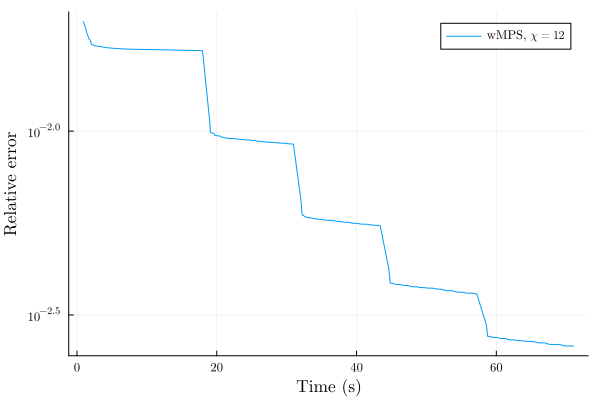

In [ ]:
using Plots
using LaTeXStrings

gg_fg=100 #number of L-BFGS iterations
n_scale=5 #number of refinements
ψ=groundstate_gg
state_array, history = refine_optim(ψ, 2, n_scale, μ0, c0, dmax, dmax+1, D, gg_fg ; verbosity=3, lbfgs_memory=100, model=LL_D6_minimal, metric_regulator=1e-8)

exact=-0.230661378983648 #LL with μ=1.0, c=8.0
error(x) = abs((x-exact)/exact) #relative error

#plotting relative error versus time
plot(history[:,1], error.(history[:,2]), seriestype=:line, label="Refinement and LBFGS")
plot!(yscale=:log10)
plot!(fontfamily = "Computer Modern")
xlabel!("Time (s)")
ylabel!("Relative error")

## Further examples

The `examples/` folder also has standalone scripts, which run in the same environment (e.g. `julia --project=examples examples/groundstate.jl` from the package root):

- `groundstate.jl`: $D6$ and $D8$ groundstates at fixed resolution, compared with the exact energy density
- `finite_chain.jl`: DMRG on a finite chain, and the density profile near the edges
- `custom_wavelet.jl`: building the exact minimal MPO from your own coefficients, or from any finite range term list
- `timing_histories.jl`: convergence of VUMPS followed by L-BFGS versus time, with `find_groundstate_t` and `add_histories`